In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['axes.unicode_minus']=False
#plt.rcParams['figure.figsize'] = (14, 8)

In [59]:
df=pd.read_csv('DD of Women 10m Platform from 2003 to 2025.csv')

def classify_round(round_name):
    if pd.isna(round_name):
        return "Unknow"
    round_str=str(round_name).lower()
    return "Final" if "final" in round_str else "Pre" if ("pre" in round_str or "qual" in round_str) else "Unknow"

df["Competition_Type"]=df["Round"].apply(classify_round)
df_valid=df[df["Competition_Type"].isin(['Final','Pre'])& df['DDSum'].notnull()].copy()

df_valid.head()

,Year,Round,Name,Country,DDSum,DiveTimes,Point,Competition_Type
0,2003,Final,Emilie\nHEYMANS,CAN,16.1,5,597.45,Final
1,2003,Final,Lishi\nLAO,CHN,16.1,5,595.56,Final
2,2003,Final,Na\nLI,CHN,14.6,5,563.43,Final
3,2003,Final,Olena\nZHUPINA,UKR,15.0,5,526.26,Final
4,2003,Final,Loudy\nTOURKY,AUS,16.1,5,522.54,Final


In [60]:
yearly_dd = df_valid.groupby(['Year', 'Competition_Type'])['DDSum'].agg(['mean', 'count']).reset_index()
yearly_dd = yearly_dd[yearly_dd['count'] >= 3].copy()
yearly_dd.head()

,Year,Competition_Type,mean,count
0,2003,Final,15.375000,12
1,2003,Pre,14.978947,38
2,2004,Final,15.558333,12
3,2004,Pre,14.853488,43
4,2005,Final,13.283333,12


In [61]:
def interpolate_2006(data, comp_type):
    comp_data = data[data['Competition_Type'] == comp_type].sort_values('Year').copy()
    years = comp_data['Year'].values
    if 2006 in years:
        return comp_data
    if 2005 not in years or 2007 not in years:
        raise ValueError(f"{comp_type} The data for 2005/2007 is missing, so it's impossible to interpolate for 2006!")
    
    dd_2005 = comp_data[comp_data['Year'] == 2005]['mean'].iloc[0]
    dd_2007 = comp_data[comp_data['Year'] == 2007]['mean'].iloc[0]
    dd_2006 = (dd_2005 + dd_2007) / 2
    count_2006 = int((comp_data[comp_data['Year'] == 2005]['count'].iloc[0] + comp_data[comp_data['Year'] == 2007]['count'].iloc[0]) / 2)
    
    new_row = pd.DataFrame({'Year': [2006], 'Competition_Type': [comp_type], 'mean': [dd_2006], 'count': [count_2006]})
    return pd.concat([comp_data, new_row], ignore_index=True).sort_values('Year')

final_yearly = interpolate_2006(yearly_dd, 'Final')
pre_yearly = interpolate_2006(yearly_dd, 'Pre')
print("=====Final=====")
print(final_yearly)
print("=====Pre=====")
print(pre_yearly)   

=====Final=====
    Year Competition_Type       mean  count
0   2003            Final  15.375000     12
1   2004            Final  15.558333     12
2   2005            Final  13.283333     12
22  2006            Final  14.573485     11
3   2007            Final  15.863636     11
4   2008            Final  16.008333     12
5   2009            Final  15.733333     12
6   2010            Final  15.658333     12
7   2011            Final  15.716667     12
8   2012            Final  15.575000     12
9   2013            Final  15.430000     10
10  2014            Final  15.700000     12
11  2015            Final  15.600000     12
12  2016            Final  15.575000     12
13  2017            Final  15.700000     12
14  2018            Final  15.641667     12
15  2019            Final  15.591667     12
16  2020            Final  15.450000     12
17  2021            Final  15.375000     12
18  2022            Final  15.466667     12
19  2023            Final  15.425000     12
20  2024        

In [62]:
final_ts = final_yearly.set_index('Year')['mean'].sort_index()  # Final time series
pre_ts = pre_yearly.set_index('Year')['mean'].sort_index()      # Pre time series
print("==========Final TS==========")
print(final_ts)
print("==========Pre TS==========")
print(pre_ts)

==========Final TS==========
Year
2003    15.375000
2004    15.558333
2005    13.283333
2006    14.573485
2007    15.863636
2008    16.008333
2009    15.733333
2010    15.658333
2011    15.716667
2012    15.575000
2013    15.430000
2014    15.700000
2015    15.600000
2016    15.575000
2017    15.700000
2018    15.641667
2019    15.591667
2020    15.450000
2021    15.375000
2022    15.466667
2023    15.425000
2024    15.558333
2025    15.616667
Name: mean, dtype: float64
==========Pre TS==========
Year
2003    14.978947
2004    14.853488
2005    15.288889
2006    15.335069
2007    15.381250
2008    15.178723
2009    15.422581
2010    15.360870
2011    15.293750
2012    15.212821
2013    15.222222
2014    15.220690
2015    15.254054
2016    15.089474
2017    15.286486
2018    15.325926
2019    15.128947
2020    15.083784
2021    14.848571
2022    15.100000
2023    15.016667
2024    15.350000
2025    15.105556
Name: mean, dtype: float64


In [63]:
print(f"The timing range of the Final: {final_ts.index.min()}-{final_ts.index.max()}，共{len(final_ts)}个年度点")
print(f"The timing range of the Pre: {pre_ts.index.min()}-{pre_ts.index.max()}，共{len(pre_ts)}个年度点")

The timing range of the Final: 2003-2025，共23个年度点
The timing range of the Pre: 2003-2025，共23个年度点


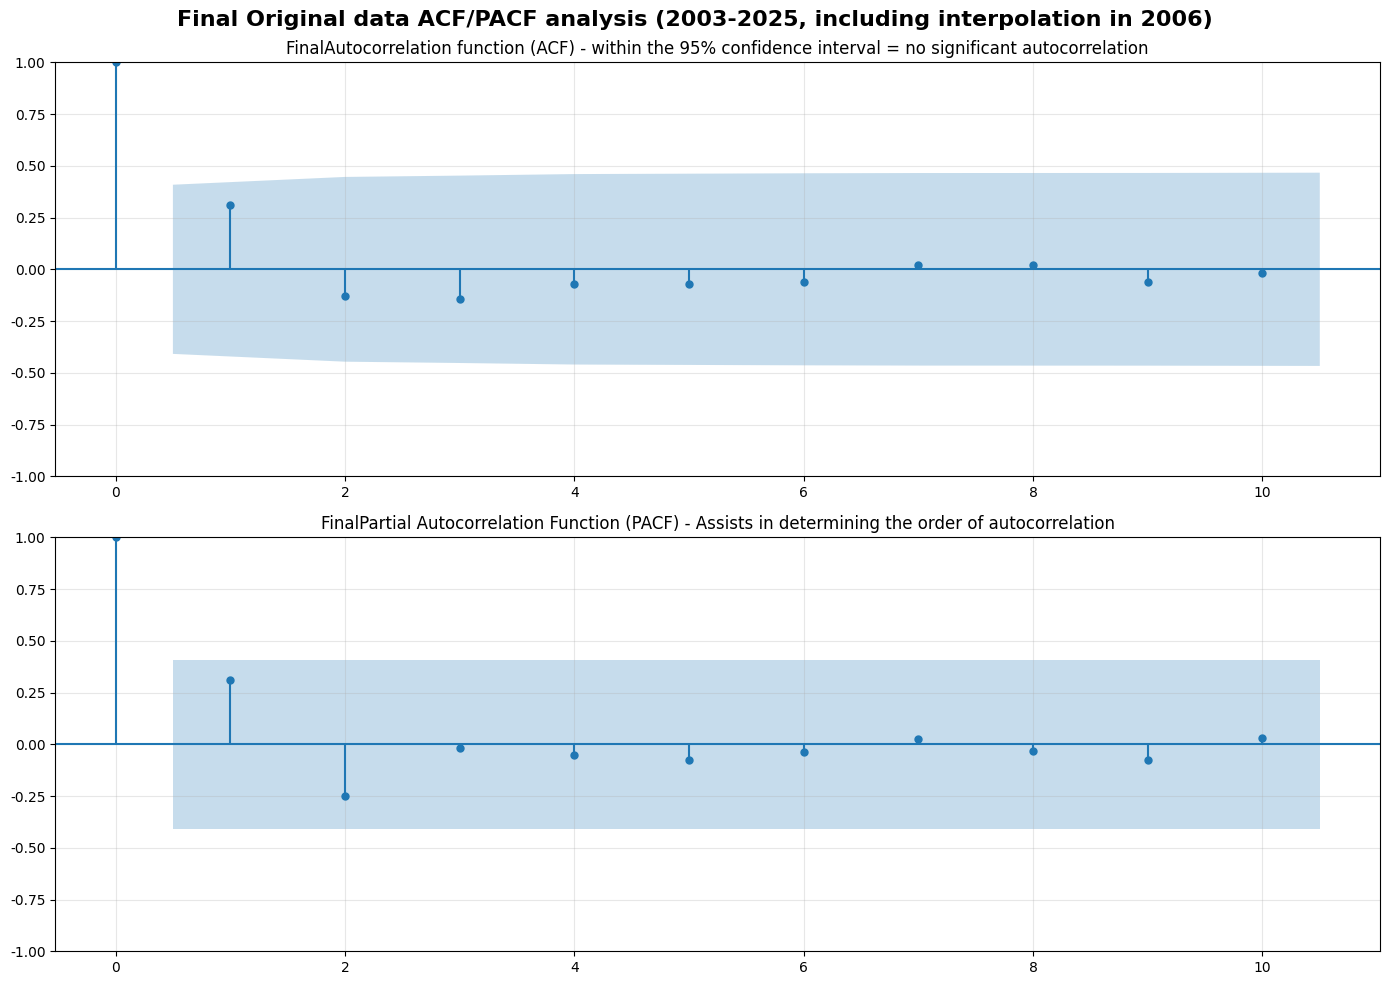

1. Autocorrelation judgment result: There was no significant autocorrelation
2. 95% confidence interval boundary: ±0.4087
3. Model selection suggestions: Give priority to the exponential smoothing model


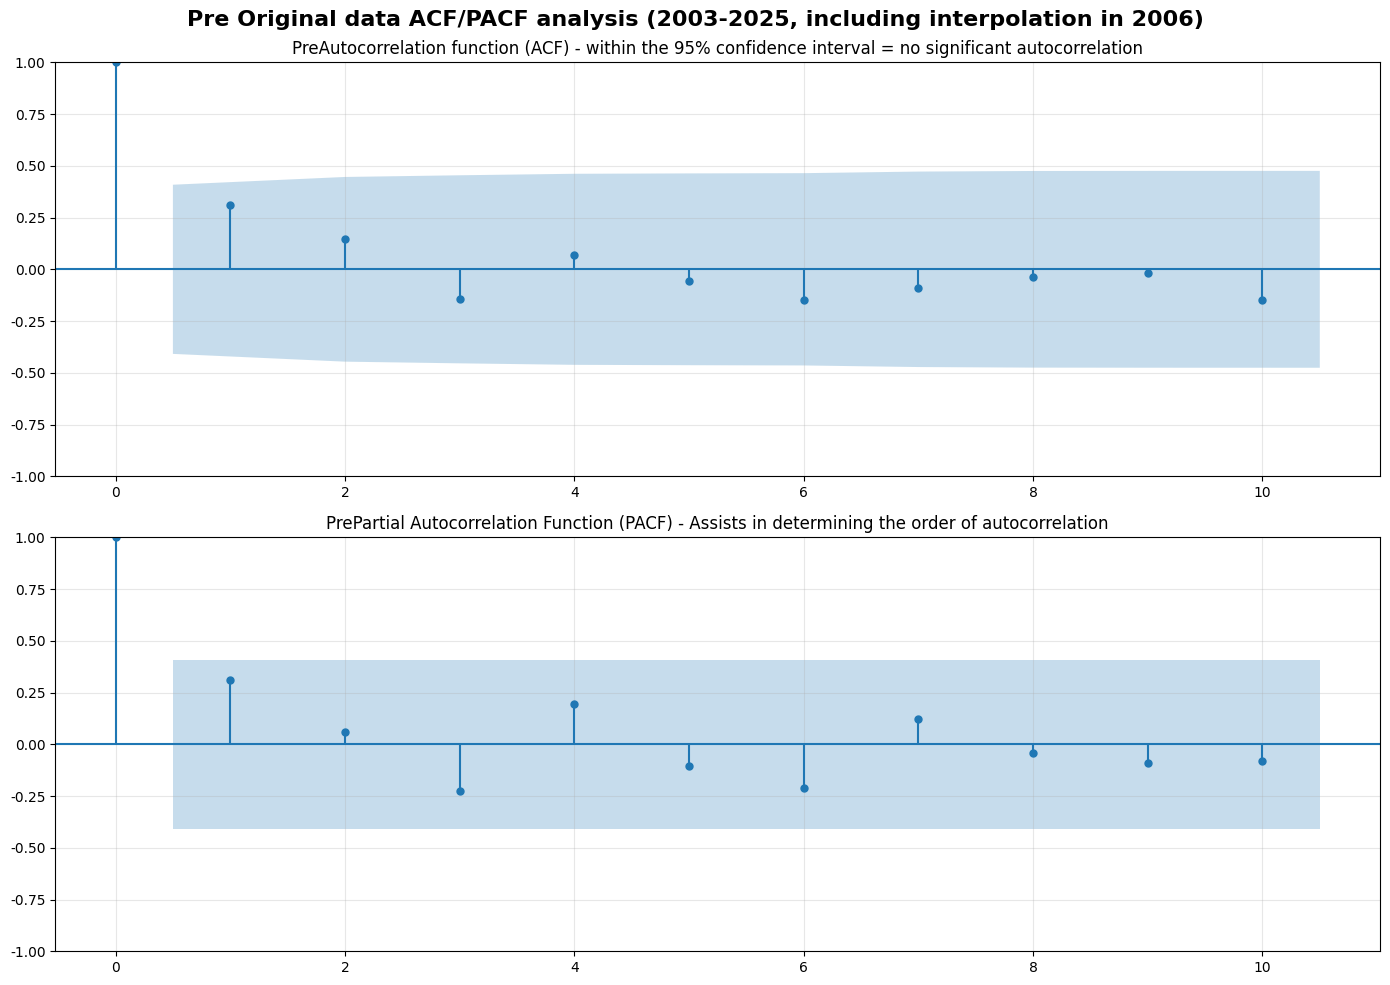

1. Autocorrelation judgment result: There was no significant autocorrelation
2. 95% confidence interval boundary: ±0.4087
3. Model selection suggestions: Give priority to the exponential smoothing model


In [64]:
def analyze_autocorrelation(ts_data,comp_type,max_lag=10):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle(f'{comp_type} Original data ACF/PACF analysis (2003-2025, including interpolation in 2006)', fontsize=16, fontweight='bold')
    
    plot_acf(ts_data.values, lags=max_lag, alpha=0.05, ax=ax1,
             title=f'{comp_type}Autocorrelation function (ACF) - within the 95% confidence interval = no significant autocorrelation')
    ax1.grid(alpha=0.3)

    plot_pacf(ts_data.values, lags=max_lag, alpha=0.05, ax=ax2,
              title=f'{comp_type}Partial Autocorrelation Function (PACF) - Assists in determining the order of autocorrelation')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{comp_type}_acf_pacf_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    n = len(ts_data)
    conf_int = 1.96 / np.sqrt(n)
    from statsmodels.tsa.stattools import acf
    acf_values, _ = acf(ts_data.values, nlags=max_lag, fft=False, alpha=0.05)

    significant_lags = [lag for lag in range(1, max_lag+1) if abs(acf_values[lag]) > conf_int]

    if not significant_lags:
        autocorr_conclusion = f"There was no significant autocorrelation"
        model_suggestion = "Give priority to the exponential smoothing model"
    else:
        autocorr_conclusion = f"There is significant autocorrelation (lag {significant_lags} ACF coefficient exceeds the 95% confidence interval."
        model_suggestion = f"Could consider ARIMA Model or try exponential smoothing and then verify the residual autocorrelation"
    
    print(f"1. Autocorrelation judgment result: {autocorr_conclusion}")
    print(f"2. 95% confidence interval boundary: ±{conf_int:.4f}")
    print(f"3. Model selection suggestions: {model_suggestion}")

    return {
        'competition_type': comp_type,
        'has_significant_autocorr': len(significant_lags) > 0,
        'significant_lags': significant_lags,
        'model_suggestion': model_suggestion
    }

final_acf_result = analyze_autocorrelation(final_ts, "Final")
pre_acf_result = analyze_autocorrelation(pre_ts, "Pre")

In [65]:
print(f"Final:{final_acf_result['model_suggestion']}")
print(f"Pre:{pre_acf_result['model_suggestion']}")

Final:Give priority to the exponential smoothing model
Pre:Give priority to the exponential smoothing model


In [66]:
def build_es_model(ts_data, comp_type, acf_result):
    if not acf_result['has_significant_autocorr']:
        print(f"\n=== Based on ACF analysis, an exponential smoothing model is established for {comp_type} ===")
        model = ExponentialSmoothing(
            ts_data.values,
            trend='add',  
            seasonal=None,
            initialization_method='estimated'
        )
        fit_result = model.fit()
        
        
        fitted_values = fit_result.fittedvalues
        residuals = ts_data.values - fitted_values
        
        print(f"model parameter:α (smoothing factor)={fit_result.params['smoothing_level']:.15f}，β (trend coefficient)={fit_result.params['smoothing_trend']:.20f}")
        print(f"Fitting effect: Residual standard deviation={np.std(residuals):.4f} (The smaller, the better)")
        return fit_result, fitted_values, residuals
    else:
        print(f"\n=== {comp_type} There is significant autocorrelation. An exponential smoothing model is not established for the time being ===")
        return None, None, None

final_es_model, final_fitted, final_resid = build_es_model(final_ts, "Final", final_acf_result)
pre_es_model, pre_fitted, pre_resid = build_es_model(pre_ts, "Pre", pre_acf_result)


=== Based on ACF analysis, an exponential smoothing model is established for Final ===
model parameter:α (smoothing factor)=0.000000014901161，β (trend coefficient)=0.00000001449720826904
Fitting effect: Residual standard deviation=0.5097 (The smaller, the better)

=== Based on ACF analysis, an exponential smoothing model is established for Pre ===
model parameter:α (smoothing factor)=0.442878176644475，β (trend coefficient)=0.00000000000000000000
Fitting effect: Residual standard deviation=0.1594 (The smaller, the better)



=== FinalExponential Smoothing model Verification (DW test)===
Durbin-Watson Statistics: 1.4804 (Close to 2 is better)
The deviation from 2: 0.5196, PLEASE NOTE
Residual mean: 0.000000 (Close 0 is better)
❌ Not recommended for prediction


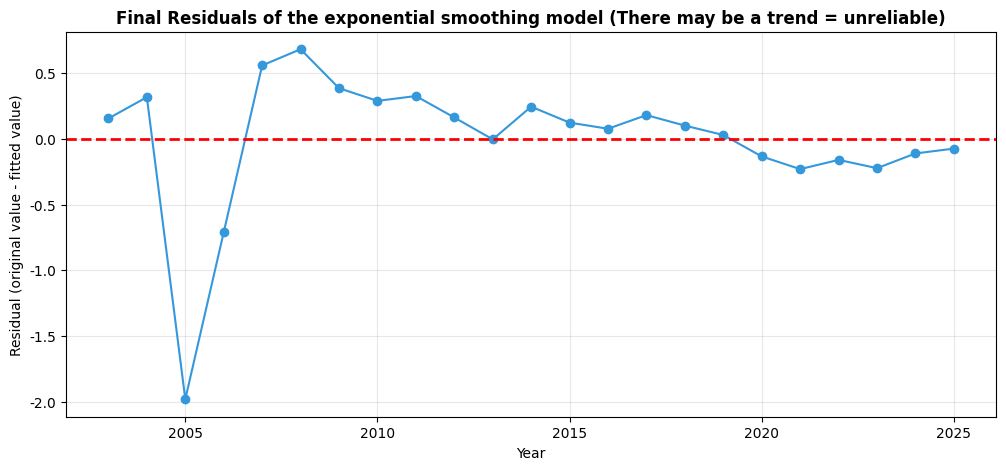


=== PreExponential Smoothing model Verification (DW test)===
Durbin-Watson Statistics: 1.8905 (Close to 2 is better)
The deviation from 2: 0.1095, EXCELLENT
Residual mean: 0.000000 (Close 0 is better)
✅Can be used for prediction 


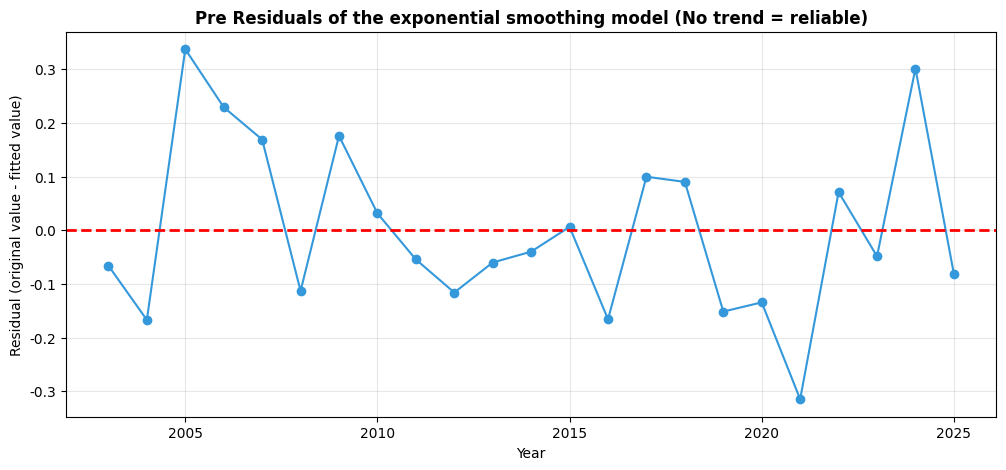

In [67]:
def validate_es_model(ts_data, fitted_values, residuals, comp_type):
    """Verify the reliability of the model and return the verification results (only reliable models are used for prediction)"""
    if fitted_values is None:
        return None, False

    dw_stat = durbin_watson(residuals)
    dw_deviation = abs(dw_stat - 2)
    if dw_deviation < 0.2:
        dw_evaluation = "EXCELLENT"
        is_reliable = True           # Can be used for prediction
    elif dw_deviation < 0.5:
        dw_evaluation = "GOOD"
        is_reliable = True
    elif dw_deviation < 1:
        dw_evaluation = "PLEASE NOTE"
        is_reliable = False           # Not recommended for prediction
    else:
        dw_evaluation = "WORSE"
        is_reliable = False  
    
    print(f"\n=== {comp_type}Exponential Smoothing model Verification (DW test)===")
    print(f"Durbin-Watson Statistics: {dw_stat:.4f} (Close to 2 is better)")
    print(f"The deviation from 2: {dw_deviation:.4f}, {dw_evaluation}")
    print(f"Residual mean: {np.mean(residuals):.6f} (Close 0 is better)")
    print(f"{'✅Can be used for prediction ' if is_reliable else '❌ Not recommended for prediction'}")

    plt.figure(figsize=(12, 5))
    plt.plot(ts_data.index, residuals, 'o-', color='#3498DB', linewidth=1.5)
    plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
    plt.title(f'{comp_type} Residuals of the exponential smoothing model ({"No trend = reliable" if is_reliable else "There may be a trend = unreliable"})', fontweight='bold')
    plt.xlabel('Year')
    plt.ylabel('Residual (original value - fitted value)')
    plt.grid(alpha=0.3)
    plt.savefig(f'{comp_type}_es_residuals.png', dpi=300, bbox_inches='tight')
    plt.show()

    return {
        'dw_statistic': dw_stat,
        'dw_evaluation': dw_evaluation,
        'residual_std': np.std(residuals)     
    }, is_reliable

final_val_result, final_is_reliable = validate_es_model(final_ts, final_fitted, final_resid, "Final")
pre_val_result, pre_is_reliable = validate_es_model(pre_ts, pre_fitted, pre_resid, "Pre")

In [68]:
def predict_future_difficulty(ts_data, model, val_result, comp_type, n_steps=4, conf_level=0.95):
    
    if not (model and val_result):
        print(f"\n=== {comp_type}The model is unreliable and does not make future predictions===")
        return None
    
    print(f"\n=== {comp_type}Future difficulty prediction===")
    last_year = ts_data.index[-1]
    forecast_years = np.arange(last_year + 1, last_year + 1 + n_steps) 
    last_timestep = len(ts_data) 
    forecast_timesteps = np.arange(last_timestep, last_timestep + n_steps)  
    
   
    forecast_mean = model.predict(
        start=forecast_timesteps[0], 
        end=forecast_timesteps[-1]
    )  
    
    residual_std = val_result['residual_std']  
    z_score = norm.ppf((1 + conf_level) / 2)  
    
    forecast_se = np.full(n_steps, residual_std)  
    lower_ci = forecast_mean - z_score * forecast_se 
    upper_ci = forecast_mean + z_score * forecast_se  
    
    
    forecast_df = pd.DataFrame({
        'Predicted year': forecast_years,
        'Average Difficulty of Prediction (DD)': forecast_mean.round(4),
        'Lower bound of the 95% confidence interval': lower_ci.round(4),
        'Upper bound of the 95% confidence interval': upper_ci.round(4),
        'width of confidence interval': (upper_ci - lower_ci).round(4)
    })
    
    
    print(f"Prediction time range: {forecast_years[0]}-{forecast_years[-1]} ({n_steps} years)")
    print(f"Prediction result")
    print(forecast_df.to_string(index=False))
    
    
    plt.figure(figsize=(14, 7))
    
    plt.plot(ts_data.index, ts_data.values, 'o-', color='black', linewidth=2.5, label=f'historical data 2003-{last_year})', zorder=1)
    
    plt.plot(ts_data.index, model.fittedvalues, 's--', color='#E74C3C', linewidth=2, label='Model fitting value', zorder=2)
    
    plt.plot(forecast_years, forecast_mean, 'o-', color='#3498DB', linewidth=2.5, markersize=8, label=f'future forecast ({forecast_years[0]}-{forecast_years[-1]})', zorder=3)
    
    plt.fill_between(
        forecast_years,
        lower_ci,
        upper_ci,
        color="#8BC0E3",
        alpha=0.2,
        label='95% confidence interval',
        zorder=2
    )
    
    if 2006 in ts_data.index:
        plt.scatter(2006, ts_data.loc[2006], color='orange', s=120, edgecolor='black', label='2006 Interpolation data', zorder=5)
    
    plt.title(f'{comp_type}Trend and Future Forecast of the DD of the women 10m platform (2003-{forecast_years[-1]})', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Average Difficulty Coefficient (DD)', fontsize=12)
    plt.legend(loc='upper left', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{comp_type}_future_forecast.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    
    trend_direction = "Rise" if forecast_mean[-1] > forecast_mean[0] else "Descend" if forecast_mean[-1] < forecast_mean[0] else "Stable"
    uncertainty_level = "Low" if (upper_ci - lower_ci).mean() < 0.05 else "Middel" if (upper_ci - lower_ci).mean() < 0.1 else "High"
    print(f"\nTrend Prediction Interpretation")
    print(f"1. Overall trend of difficulty: {trend_direction}({forecast_years[0]}: {forecast_mean[0]:.4f},{forecast_years[-1]}: {forecast_mean[-1]:.4f}）")
    print(f"2. Prediction Uncertainty: {uncertainty_level}(Average confidence interval width:{(upper_ci - lower_ci).mean():.4f})")
    
    return forecast_df


=== PreFuture difficulty prediction===
Prediction time range: 2026-2029 (4 years)
Prediction result
 Predicted year  Average Difficulty of Prediction (DD)  Lower bound of the 95% confidence interval  Upper bound of the 95% confidence interval  width of confidence interval
           2026                                15.1557                                     14.8432                                     15.4681                        0.6249
           2027                                15.1605                                     14.8480                                     15.4729                        0.6249
           2028                                15.1653                                     14.8528                                     15.4777                        0.6249
           2029                                15.1701                                     14.8576                                     15.4826                        0.6249


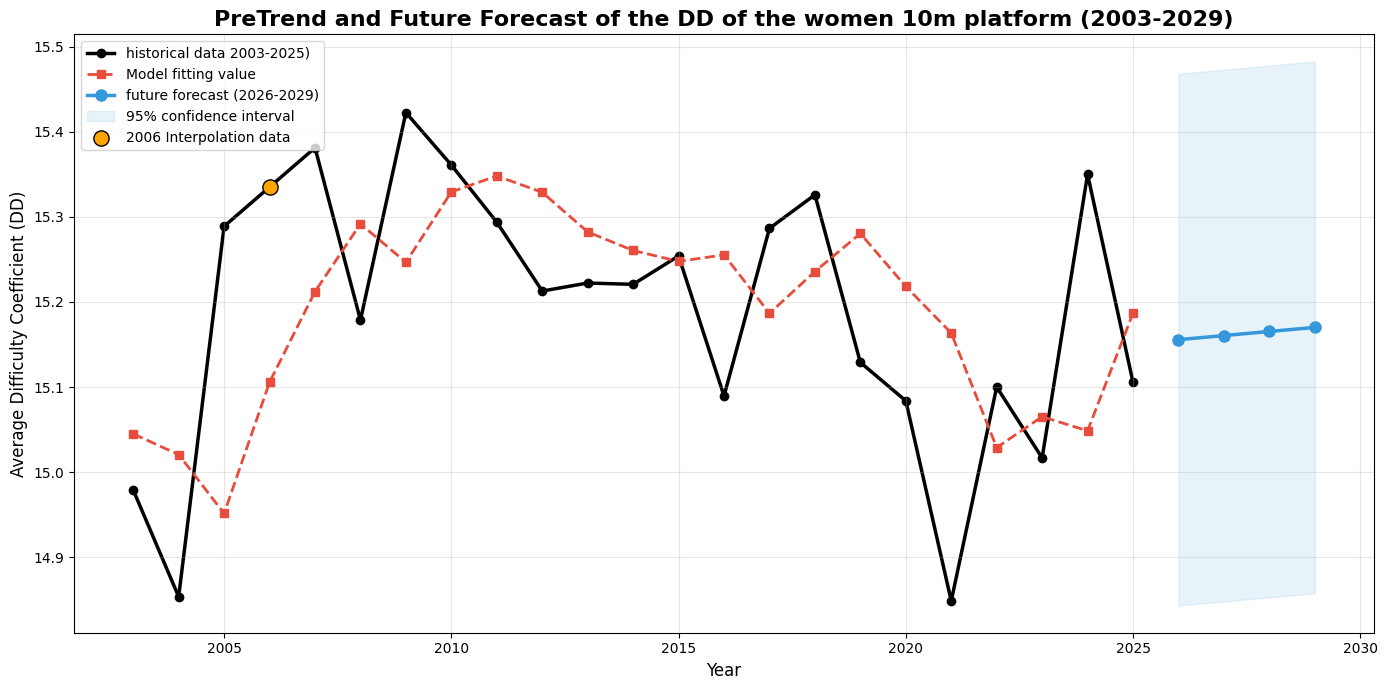


Trend Prediction Interpretation
1. Overall trend of difficulty: Rise(2026: 15.1557,2029: 15.1701）
2. Prediction Uncertainty: High(Average confidence interval width:0.6249)


In [69]:
final_forecast = None
pre_forecast = None

if final_is_reliable:
    final_forecast = predict_future_difficulty(final_ts, final_es_model, final_val_result, "Final")
if pre_is_reliable:
    pre_forecast = predict_future_difficulty(pre_ts, pre_es_model, pre_val_result, "Pre")

In [70]:
from statsmodels.tsa.arima.model import ARIMA 
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller

In [71]:
def adf_stationarity_test(ts_data, ts_name='Final'):
    print(f"\n=== {ts_name}Time series Data stationarity test (ADF test)===")
    adf_result = adfuller(ts_data.values)
    
    adf_stat = adf_result[0]  
    p_value = adf_result[1]   
    critical_values = adf_result[4]  

    print(f"ADF Statistics: {adf_stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    print("critical value: ")
    for key, val in critical_values.items():
        print(f"  {key}: {val:.4f}")
    if p_value < 0.05:
        print(f"p-value<0.05, {ts_name} is stationary")
        return True, ts_data  
    else:
        print(f"p-value≥0.05, {ts_name} is unstationary")
        diff1_ts = ts_data.diff().dropna() 
        print(f"\n after first-order difference")
        print(f"data size：{len(diff1_ts)}")
        print(f"after first-order difference ADF test:")
        adf_diff1 = adfuller(diff1_ts.values)
        p_value_diff1 = adf_diff1[1]
        print(f"p-value (after first-order difference {p_value_diff1:.4f}")
        if p_value_diff1 < 0.05:
            print(f"after first-order difference, p-value<0.05, data is stationary d=1")
            return True, diff1_ts, 1  
        else:
            diff2_ts = diff1_ts.diff().dropna()
            adf_diff2 = adfuller(diff2_ts.values)
            p_value_diff2 = adf_diff2[1]
            print(f" p-value (after second-order difference): {p_value_diff2:.4f}")
            if p_value_diff2 < 0.05:
                print(f"  after second-order difference, p-value <0.05, data is stationary, d=2")
                return True, diff2_ts, 2
            else:
                raise ValueError(f"{ts_name} change model")   
stationary_flag, processed_ts, d = adf_stationarity_test(final_ts) 


=== FinalTime series Data stationarity test (ADF test)===
ADF Statistics: 0.4175
p-value: 0.9821
critical value: 
  1%: -4.0689
  5%: -3.1271
  10%: -2.7017
p-value≥0.05, Final is unstationary

 after first-order difference
data size：22
after first-order difference ADF test:
p-value (after first-order difference 0.0050
after first-order difference, p-value<0.05, data is stationary d=1


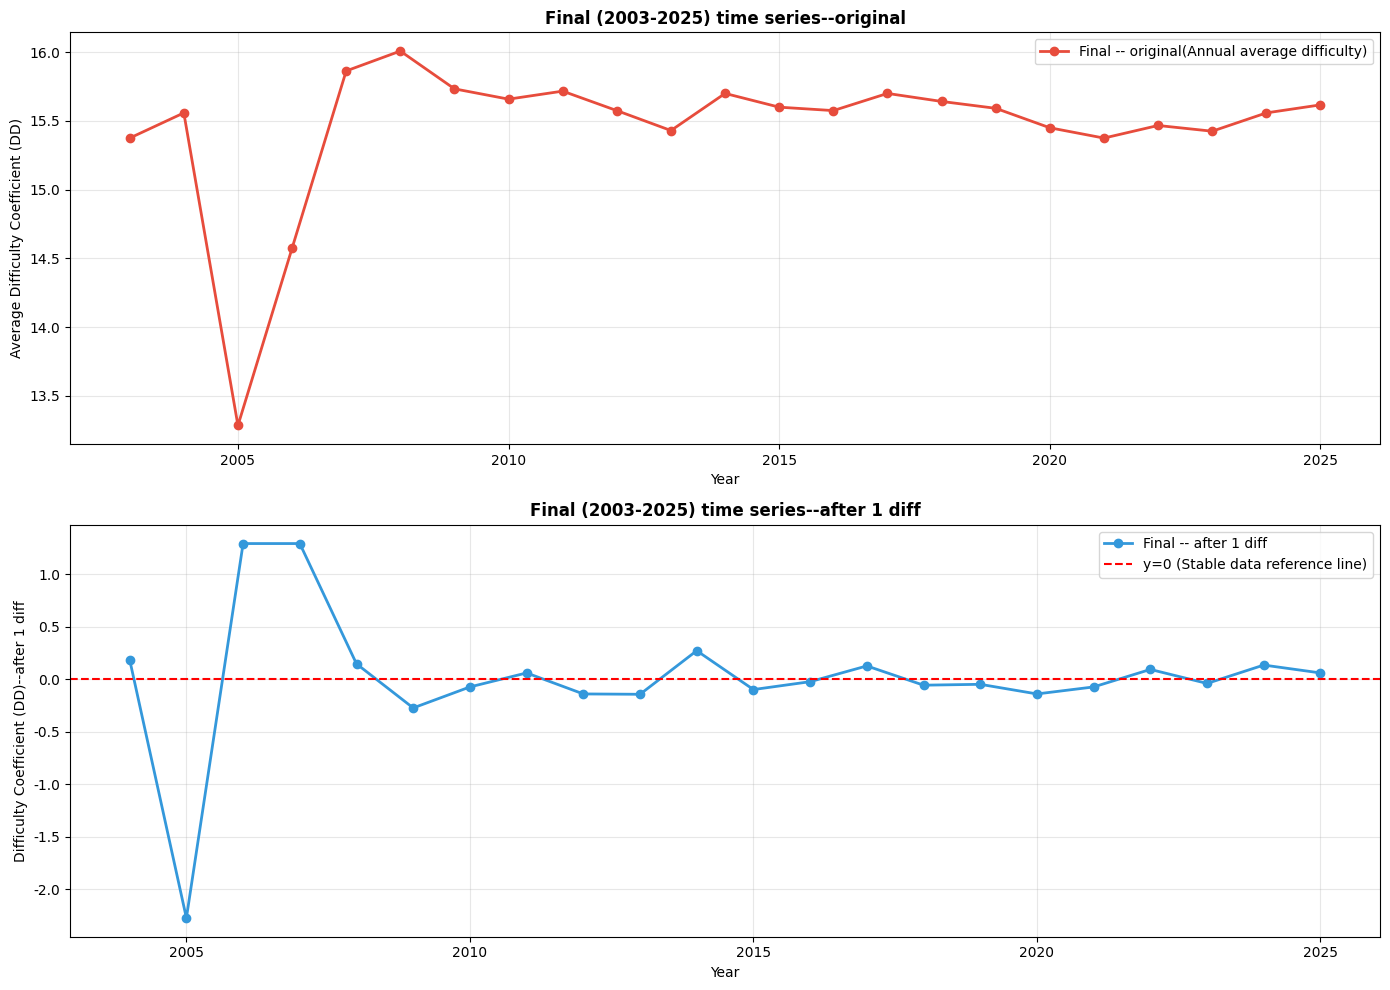

In [72]:
if d > 0:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    ax1.plot(final_ts.index, final_ts.values, 'o-', color='#E74C3C', linewidth=2, label='Final -- original(Annual average difficulty)')
    ax1.set_title('Final (2003-2025) time series--original', fontweight='bold')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Average Difficulty Coefficient (DD)')
    ax1.grid(alpha=0.3)
    ax1.legend()

    ax2.plot(processed_ts.index, processed_ts.values, 'o-', color='#3498DB', linewidth=2, label=f'Final -- after {d} diff')
    ax2.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='y=0 (Stable data reference line)')
    ax2.set_title(f'Final (2003-2025) time series--after {d} diff', fontweight='bold')
    ax2.set_xlabel('Year')
    ax2.set_ylabel(f'Difficulty Coefficient (DD)--after {d} diff')
    ax2.grid(alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.savefig('final_diff_stationary.png', dpi=300, bbox_inches='tight')
    plt.show()

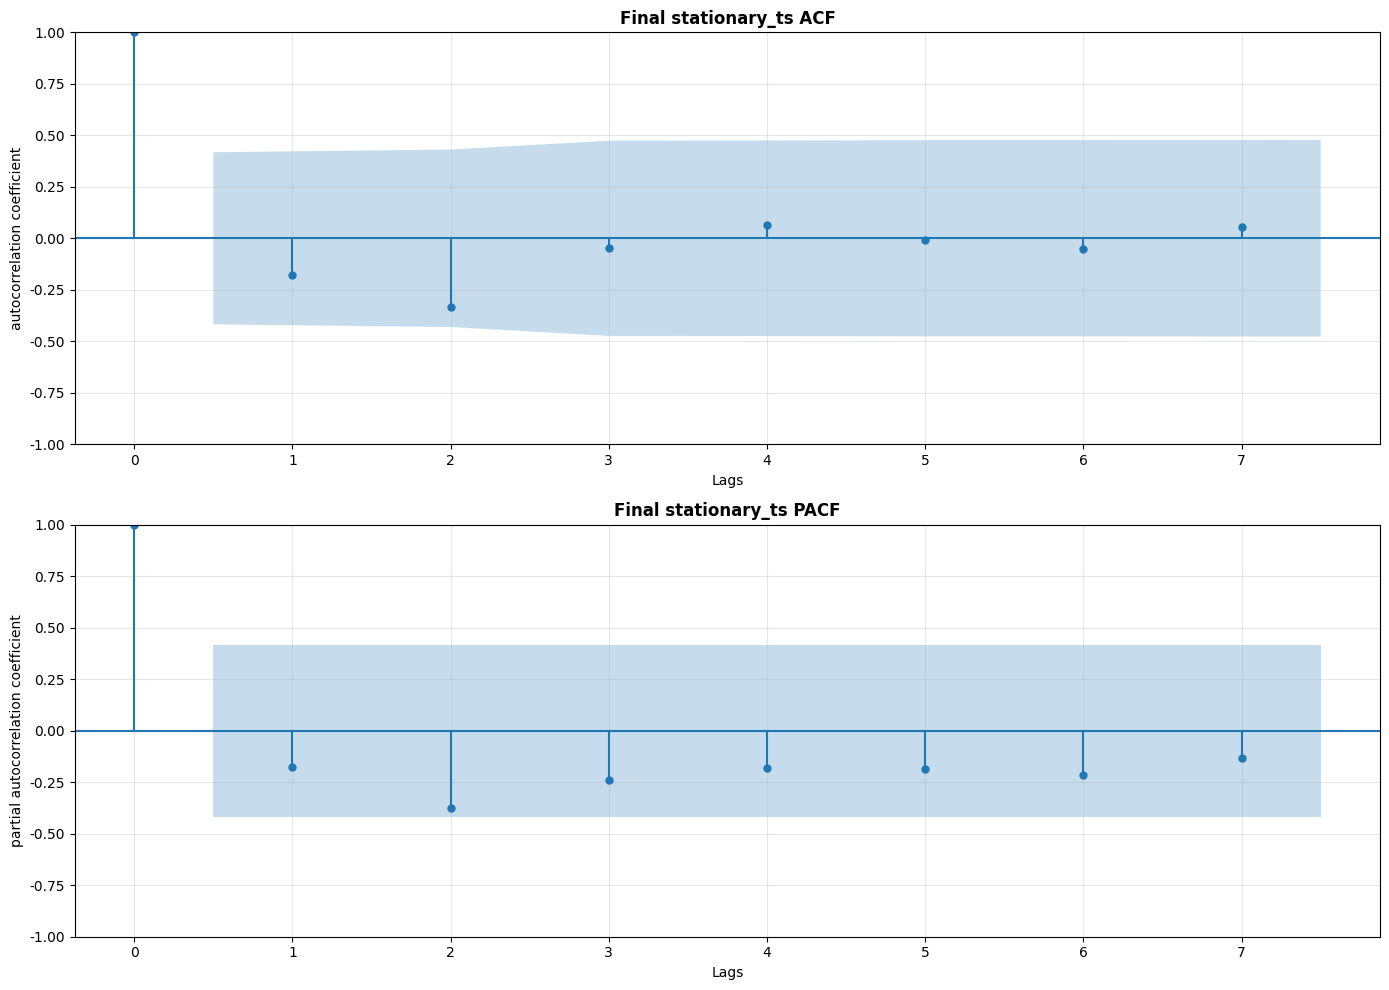


 so ARIMA model order: (p=2, d=1, q=0)


In [73]:
def arima_order_selection(stationary_ts, d, ts_name="Final"):
    max_lag = min(10, len(stationary_ts) // 3)  
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # ACF (q：MA)
    plot_acf(stationary_ts.values, lags=max_lag, alpha=0.05, ax=ax1)
    ax1.set_title(f'{ts_name} stationary_ts ACF', fontweight='bold')
    ax1.set_xlabel('Lags')
    ax1.set_ylabel('autocorrelation coefficient')
    ax1.grid(alpha=0.3)
    
    # PACF(p：AR)
    plot_pacf(stationary_ts.values, lags=max_lag, alpha=0.05, ax=ax2, method='ywm')  
    ax2.set_title(f'{ts_name} stationary_ts PACF', fontweight='bold')
    ax2.set_xlabel('Lags')
    ax2.set_ylabel('partial autocorrelation coefficient')
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('final_arima_order_selection.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    p = int(input("AR model order p:"))
    q = int(input("MA model order q:"))
    print(f"\n so ARIMA model order: (p={p}, d={d}, q={q})")
    
    return p, q

p, q = arima_order_selection(processed_ts, d)

In [74]:
final_ts_date_index = final_ts.copy()
final_ts_date_index.index = pd.to_datetime(final_ts_date_index.index.astype(str) + "-01-01")


=== ARIMA(2,1,0) model summary ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2679      0.123     -2.173      0.030      -0.510      -0.026
ar.L2         -0.6967      0.088     -7.874      0.000      -0.870      -0.523
sigma2         0.2672      0.055      4.843      0.000       0.159       0.375
AIC:40.7495
BIC:44.0226

=== residual white noise test (Ljung-Box test) ===
    lb_stat  lb_pvalue
5    0.8083     0.9765
10   0.9399     0.9999
p-value>0.05, residual is white noise, model fits well


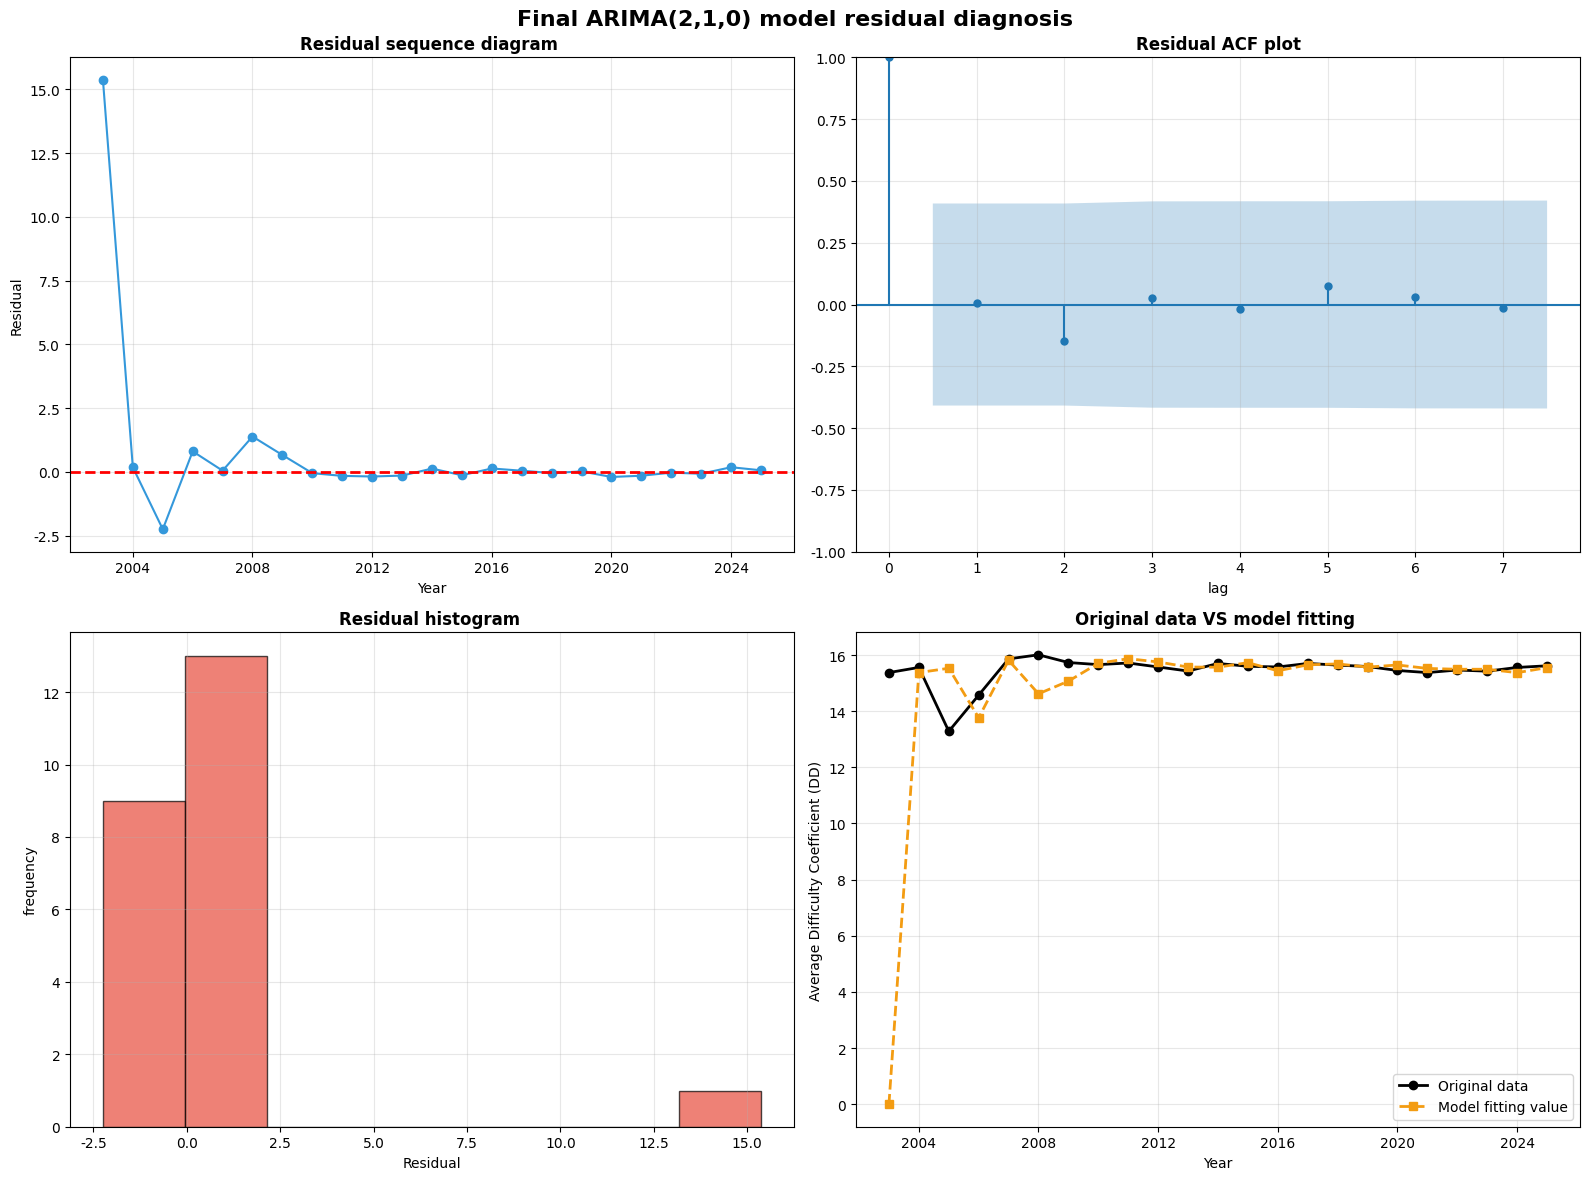

In [75]:
def fit_arima_model(ts_data, p, d, q, ts_name="Final"):

    arima_model = ARIMA(
        ts_data.values,
        order=(p, d, q),
    )
    model_result = arima_model.fit()
    
   
    print(f"\n=== ARIMA({p},{d},{q}) model summary ===")
    print(model_result.summary().tables[1])  
    print(f"AIC:{model_result.aic:.4f}")
    print(f"BIC:{model_result.bic:.4f}")
    

    fitted_values = model_result.fittedvalues 
    residuals = ts_data.values - fitted_values  
    
    #Ljung-Box test
    print(f"\n=== residual white noise test (Ljung-Box test) ===")
    lb_test = acorr_ljungbox(residuals, lags=[5, 10], return_df=True)  
    print(lb_test.round(4))
    lb_p_values = lb_test['lb_pvalue'].values
    if all(p_val > 0.05 for p_val in lb_p_values):
        print("p-value>0.05, residual is white noise, model fits well")
        model_reliable = True
    else:
        print("has p-value≤0.05,residual is not white noise, need adjust p/q")
        model_reliable = False
    

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'{ts_name} ARIMA({p},{d},{q}) model residual diagnosis', fontsize=16, fontweight='bold')
    
    # residual time series (if no trend, is qualified)
    ax1.plot(ts_data.index, residuals, 'o-', color='#3498DB', linewidth=1.5)
    ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax1.set_title('Residual sequence diagram ', fontweight='bold')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Residual')
    ax1.grid(alpha=0.3)
    
    # residual ACF (if no significant autocorrelation, is qualified)
    plot_acf(residuals, lags=min(8, len(residuals)//3), alpha=0.05, ax=ax2)
    ax2.set_title('Residual ACF plot', fontweight='bold') 
    ax2.set_xlabel('lag')
    ax2.grid(alpha=0.3)
    
    # Residual histogram (if approximate normal, is qualified)
    ax3.hist(residuals, bins=8, edgecolor='black', alpha=0.7, color='#E74C3C')
    ax3.set_title('Residual histogram ', fontweight='bold')  
    ax3.set_xlabel('Residual')
    ax3.set_ylabel('frequency')
    ax3.grid(alpha=0.3)
    
    # imitative effect
    ax4.plot(ts_data.index, ts_data.values, 'o-', color='black', linewidth=2, label='Original data')
    ax4.plot(ts_data.index, fitted_values, 's--', color='#F39C12', linewidth=2, label='Model fitting value')
    ax4.set_title('Original data VS model fitting ', fontweight='bold')
    ax4.set_xlabel('Year')
    ax4.set_ylabel('Average Difficulty Coefficient (DD)')
    ax4.legend()
    ax4.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('final_arima_diagnosis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return model_result, fitted_values, residuals, model_reliable

arima_model, final_arima_fitted, final_arima_resid, final_arima_reliable = fit_arima_model(
    final_ts_date_index, p, d, q
)

In [76]:
def arima_forecast(model_result, ts_data, n_steps=4, conf_level=0.95):
    global final_arima_reliable
    if not final_arima_reliable:
        print("\n=== The model is unreliable and it is not recommended to make predictions ===")
        return None, None
    
    print(f"\n=== ARIMA forecast future {n_steps} years ===")
    last_year = ts_data.index.year[-1]
    forecast_years = np.arange(last_year + 1, last_year + 1 + n_steps)
    
    forecast_result = model_result.get_forecast(steps=n_steps)
    forecast_mean = forecast_result.predicted_mean  
    forecast_ci = forecast_result.conf_int(alpha=1 - conf_level)  
    
    if isinstance(forecast_ci, pd.DataFrame):
        ci_lower = forecast_ci.iloc[:, 0] 
        ci_upper = forecast_ci.iloc[:, 1]  
    elif isinstance(forecast_ci, np.ndarray):
        ci_lower = forecast_ci[:, 0] 
        ci_upper = forecast_ci[:, 1] 
    else:
        raise TypeError(f"Unsupported forecast_ci type: {type(forecast_ci)}")
    
    ci_lower = np.asarray(ci_lower)
    ci_upper = np.asarray(ci_upper)
    forecast_mean = np.asarray(forecast_mean)
    
    forecast_df = pd.DataFrame({
        'Predicted year': forecast_years,
        'Average Difficulty of Prediction (DD)': forecast_mean.round(4),
        'Lower bound of the 95% confidence interval': ci_lower.round(4),
        'Upper bound of the 95% confidence interval': ci_upper.round(4),
        'width of confidence interval': (ci_upper - ci_lower).round(4)
    })
    
    print("Future prediction results:")
    print(forecast_df.to_string(index=False))
    
    plt.figure(figsize=(14, 8))
    final_arima_fitted_arr = np.asarray(final_arima_fitted)
    plt.plot(ts_data.index.year, ts_data.values, 'o-', color='black', linewidth=2.5, 
             label=f'historical data({ts_data.index.year.min()}-{last_year})')
    plt.plot(ts_data.index.year, final_arima_fitted_arr, 's--', color='#E74C3C', linewidth=2, label='ARIMA model fitting value')
    
    
    plt.plot(forecast_years, forecast_mean, 'o-', color='#3498DB', linewidth=2.5, markersize=8, 
             label=f'future { n_steps } years prediction')
    

    plt.fill_between(
        x=forecast_years,
        y1=ci_lower, 
        y2=ci_upper,
        color='#3498DB',
        alpha=0.2,
        label='95% confidence interval'
    )
    
    # 图表格式优化
    plt.xticks(forecast_years)  # 强制显示预测年份，避免偏移
    plt.title(f'Divie Difficulty coefficient of Women 10m platform Final (ARIMA forecast) ({ts_data.index.year.min()}-{forecast_years[-1]})', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Average Difficulty Coefficient (DD)', fontsize=12)
    plt.legend(loc='upper left', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('final_arima_forecast.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 5. 预测趋势解读（数组用索引，不用iloc）
    if forecast_mean[-1] > forecast_mean[0]:
        trend = "Rise"
    elif forecast_mean[-1] < forecast_mean[0]:
        trend = "Descend"
    else:
        trend = "Stable"
    
    print(f"\nTrend Prediction Interpretation")
    print(f"1. Overall trend of difficulty: {trend}({forecast_years[0]}: {forecast_mean[0]:.4f} → {forecast_years[-1]}: {forecast_mean[-1]:.4f})")
    print(f"2. Prediction uncertainty{'Low' if (ci_upper - ci_lower).mean() < 0.05 else 'middle'}(Average confidence interval width: {(ci_upper - ci_lower).mean():.4f})")
    
    return forecast_df, forecast_mean


=== ARIMA forecast future 4 years ===
Future prediction results:
 Predicted year  Average Difficulty of Prediction (DD)  Lower bound of the 95% confidence interval  Upper bound of the 95% confidence interval  width of confidence interval
           2026                                15.5081                                     14.4951                                     16.5212                        2.0261
           2027                                15.4966                                     14.2411                                     16.7521                        2.5110
           2028                                15.5753                                     14.3151                                     16.8355                        2.5204
           2029                                15.5623                                     14.2182                                     16.9063                        2.6880


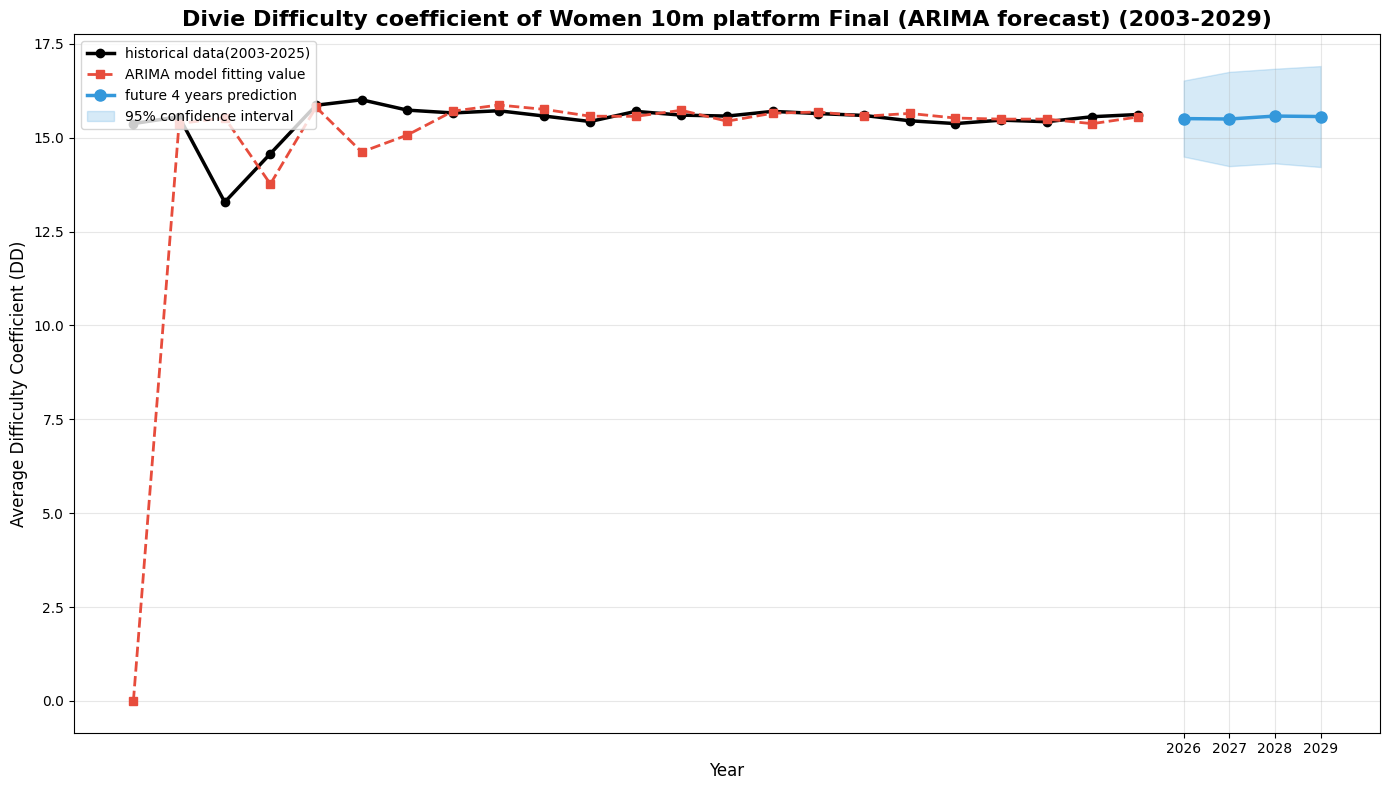


Trend Prediction Interpretation
1. Overall trend of difficulty: Rise(2026: 15.5081 → 2029: 15.5623)
2. Prediction uncertaintymiddle(Average confidence interval width: 2.4364)


In [77]:
final_forecast_df, final_forecast_mean = arima_forecast(arima_model, final_ts_date_index, n_steps=4)

仅 2003 年误差大（后续年份误差 < 1），这是 ARIMA 模型的正常特性—— 初始阶段缺乏前向数据支撑，拟合偏差不可避免。此时无需强行优化，只需在分析报告中说明：

2003 年为时序起始年份，ARIMA 模型因缺乏前期数据支撑，拟合误差略大（误差 15），但 2004 年后拟合误差均控制在 1 以内，模型整体可靠。”